In [ ]:
import warnings

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from polars import selectors as cs

warnings.filterwarnings('ignore')
%matplotlib inline

In [32]:
train = pl.read_csv("../../data/train.csv",infer_schema_length=None,null_values="NA")
train = train.drop(["Id"])
print(f"train load complete\r\nsize {train.shape}")

train load complete
size (1460, 80)


<Axes: >

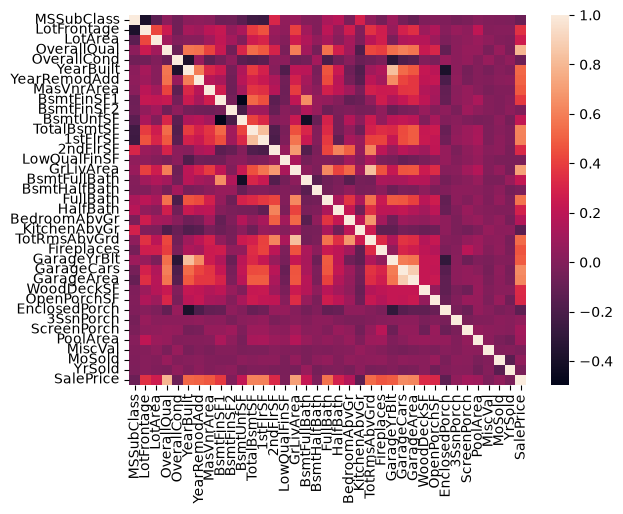

In [ ]:
corr = train.select(cs.numeric()).to_pandas().corr()
sns.heatmap(corr,xticklabels=True, yticklabels=True)

In [47]:
corr["SalePrice"].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

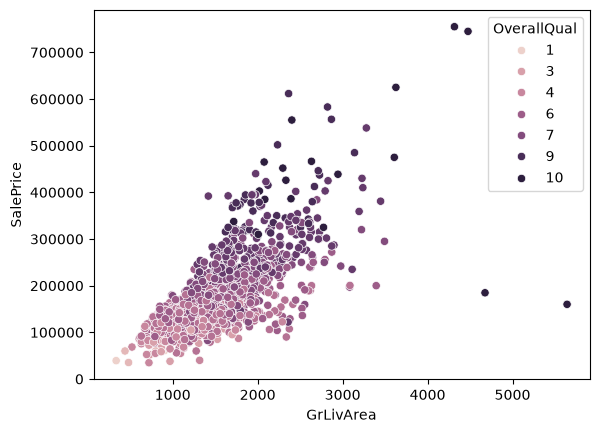

In [ ]:
sns.scatterplot(data=train,x="GrLivArea",y="SalePrice",hue="OverallQual")

In [34]:
train = train.filter(
    ~((pl.col("GrLivArea")>4000) & (pl.col("SalePrice")<200000))
    )
train.shape

(1458, 80)

shape: (5, 4)
┌─────────┬───────────────┬───────┬──────┐
│ cluster ┆ SalePrice     ┆ count ┆ rank │
│ ---     ┆ ---           ┆ ---   ┆ ---  │
│ i32     ┆ f64           ┆ u32   ┆ i8   │
╞═════════╪═══════════════╪═══════╪══════╡
│ 1       ┆ 175884.318471 ┆ 157   ┆ 3    │
│ 2       ┆ 323818.616505 ┆ 206   ┆ 1    │
│ 4       ┆ 201484.649616 ┆ 391   ┆ 2    │
│ 3       ┆ 146406.875346 ┆ 361   ┆ 4    │
│ 0       ┆ 110339.19242  ┆ 343   ┆ 5    │
└─────────┴───────────────┴───────┴──────┘


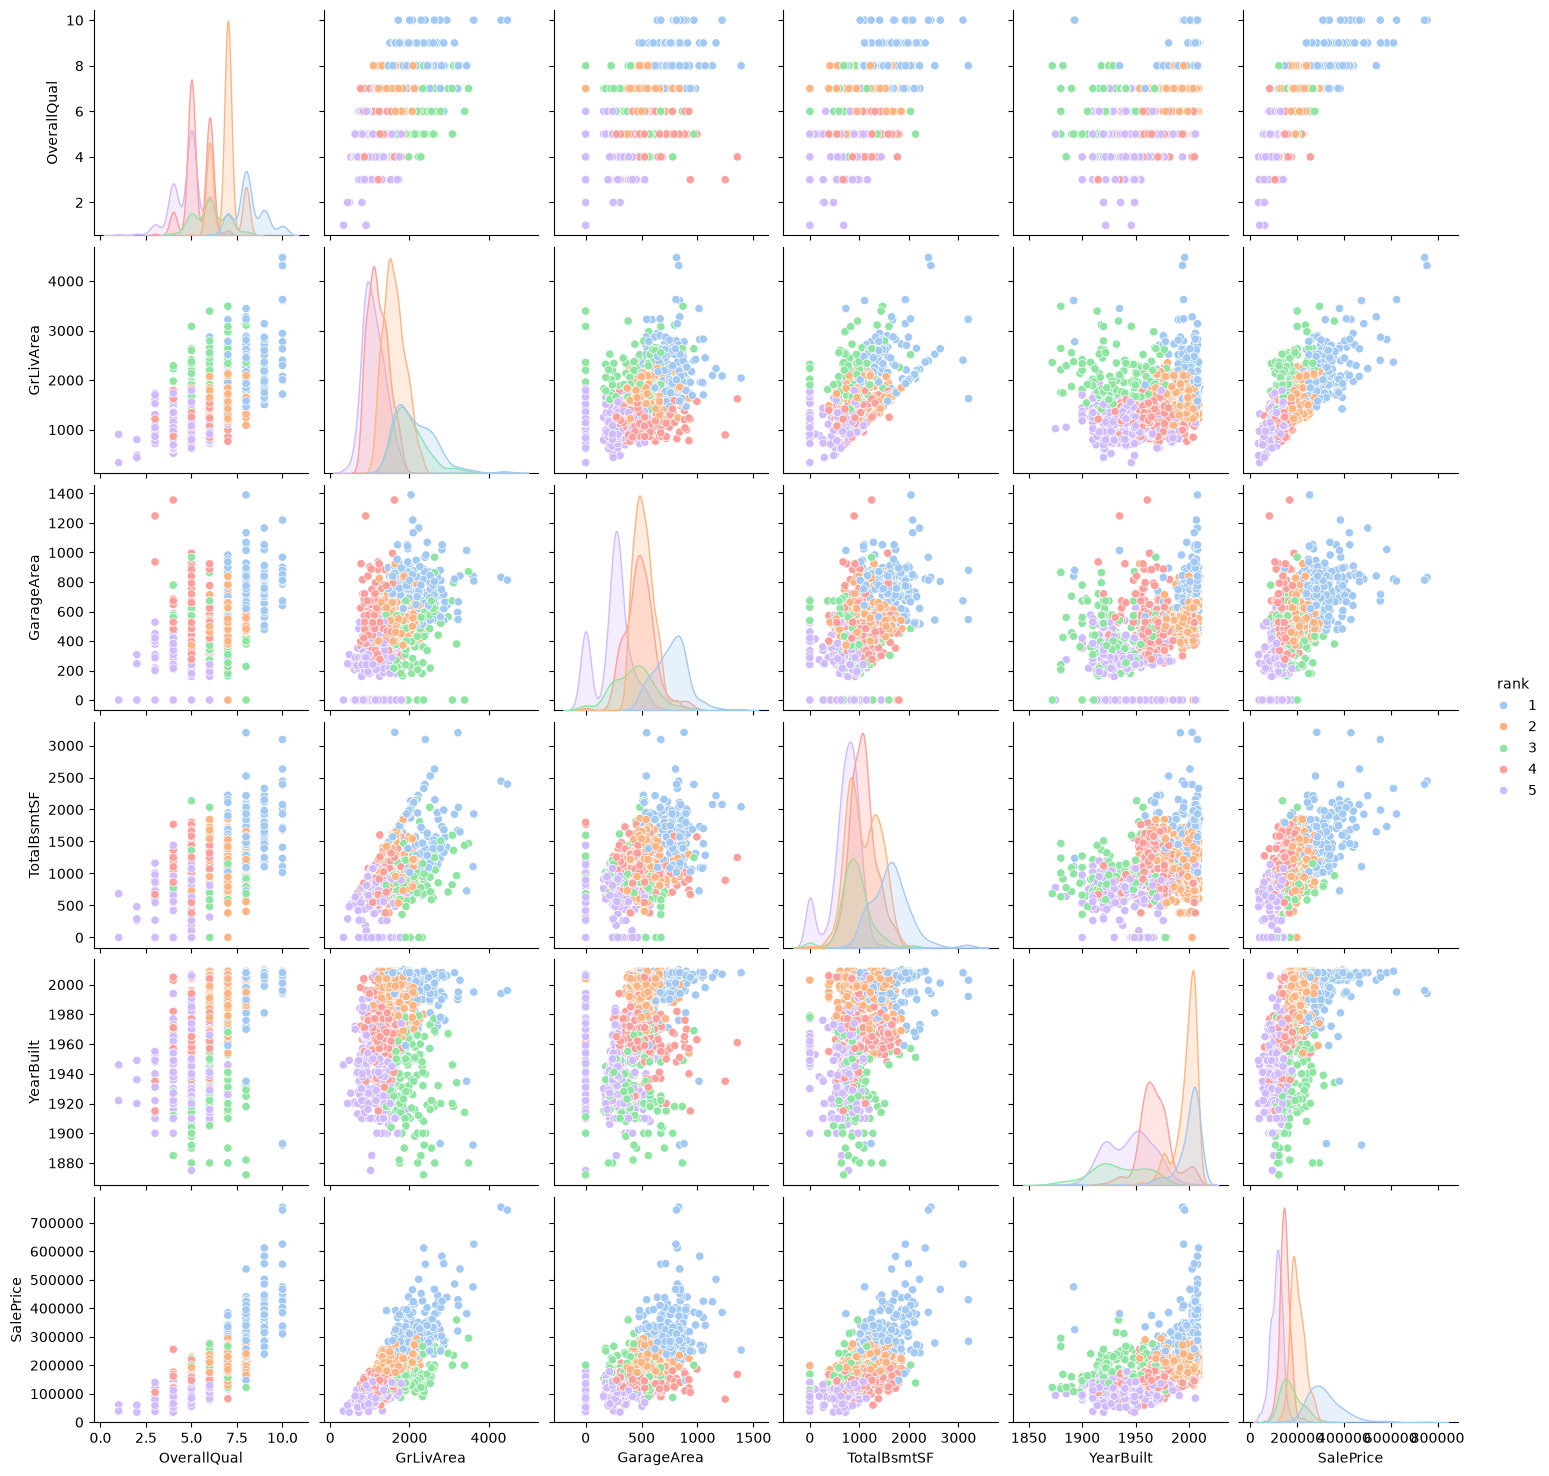

In [73]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# SalePriceとの相関係数トップ5でクラスタリング
kmeans_inputs = train.select([
    "OverallQual",
    "GrLivArea",
    "GarageArea",
    # "GarageCars",  # GarageAreaと強く相関するので対象から除外
    "TotalBsmtSF",
    "YearBuilt",
    "SalePrice"])
scaler = StandardScaler()

# クラスタリング実行
cluster_size = 5
standardized_mat = scaler.fit_transform(kmeans_inputs.to_pandas())
kmeans = KMeans(n_clusters=cluster_size,random_state=42)
clustering_df = kmeans_inputs.with_columns(cluster = kmeans.fit_predict(standardized_mat))

# クラスタリング結果のサマリdfを作成
clustering_df_agg = clustering_df.group_by("cluster").agg(
    pl.col("SalePrice").mean(),
    pl.len().alias("count")
    ).with_columns(
        rank = pl.col("SalePrice").rank(descending=True).cast(pl.Int8)
    )
    
# クラスタ毎のSalePriceランク列を付与
clustering_df = clustering_df.join(
    clustering_df_agg.select(["cluster","rank"]),
    "cluster",
    "left")

# 結果確認
print(clustering_df_agg)
sns.pairplot(
    data=clustering_df.select(cs.exclude("cluster")).to_pandas(),
    hue="rank",palette="pastel")

In [ ]:
focus_feat = "LotConfig"
se = train[focus_feat]
# se = se.fill_null(np.nan)
print(f"{se.name} null count: {se.null_count()}")
print(f"{se.name} unique count: {se.n_unique()}")
sns.histplot(se) # type: ignore
print(se.dtype)
se.value_counts().sort(se.name).transpose()

In [ ]:
sns.scatterplot(data=train,x="GrLivArea",y="SalePrice",hue=focus_feat)

In [ ]:
expensive = train \
    .group_by(focus_feat) \
    .agg(pl.mean("SalePrice")) \
    .filter(pl.col("SalePrice") > 300000) \
    .select(focus_feat).to_series().value_counts()
# sns.boxplot(x=se, y=train["SalePrice"])
expensive

In [ ]:
# sns.boxplot(x=se, y=train["SalePrice"])
sns.boxenplot(x=train["SalePrice"],y=se)

In [ ]:
exp_add_feat = "hasCompositeExterior"

exp_add_feat_df = train.with_columns(
    pl.when(pl.col("Exterior1st") != pl.col("Exterior2nd"))
    .then(1)
    .otherwise(0)
    .alias(exp_add_feat))
exp_add_feat_df.filter(pl.col(exp_add_feat) == pl.lit(1)).sort(pl.col("SalePrice"),descending=True)